# MacBook Config Coverage — Gantt View
Coverage of MacBook RAM configurations against workload options 1–6

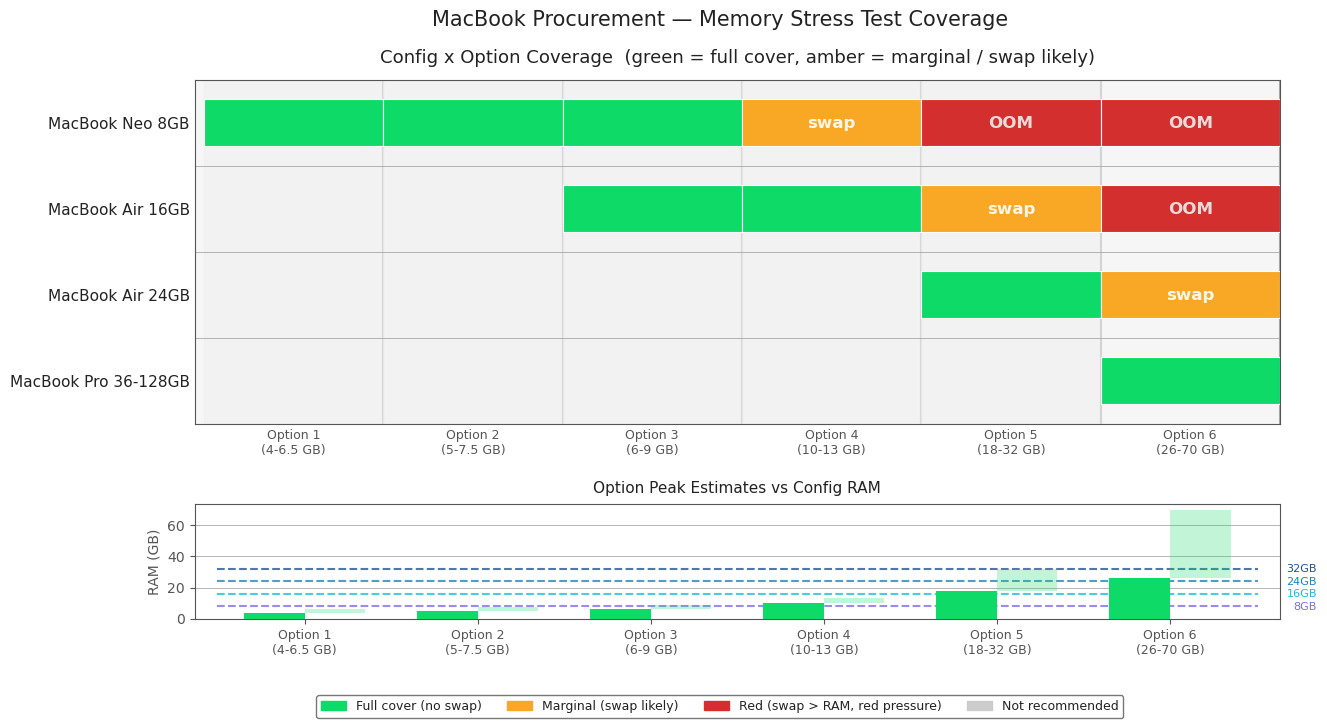

Saved -> gantt_chart.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

%matplotlib inline

configs  = ['MacBook Neo 8GB', 'MacBook Air 16GB', 'MacBook Air 24GB', 'MacBook Pro 36-128GB']
colors   = ['#6c5ce7', '#00b4d8', '#0077b6', '#023e8a']
peak_labels = ['4-6.5 GB','5-7.5 GB','6-9 GB','10-13 GB','18-32 GB','26-70 GB']
options     = [f'Option {i}\n({peak_labels[i-1]})' for i in range(1,7)]

# coverage: 1.0=full cover, 0.4=marginal (swap likely), -1.0=red (swap > RAM, red pressure)
coverage = np.array([
    [1.0,  1.0,  1.0,  0.4, -1.0, -1.0],
    [0.0,  0.0,  1.0,  1.0,  0.4, -1.0],
    [0.0,  0.0,  0.0,  0.0,  1.0,  0.4],
    [0.0,  0.0,  0.0,  0.0,  0.0,  1.0],
])

FULL_COLOR = "#0edb67"
MARG_COLOR = "#f9a825"
RED_COLOR  = "#d32f2f"
NONE_COLOR = "#cccccc"
BG_COLOR   = 'white'
GRID_COLOR = '#999999'
AXIS_COLOR = '#555555'
TEXT_COLOR = '#222222'

def get_color(val):
    if val >= 0.9: return FULL_COLOR
    if val >= 0.3: return MARG_COLOR
    if val < 0:   return RED_COLOR
    return 'none'

fig = plt.figure(figsize=(14, 7), facecolor=BG_COLOR)
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.35)
ax_gantt = fig.add_subplot(gs[0])
ax_bar   = fig.add_subplot(gs[1])

bar_h = 0.55
for ci, (cfg, col) in enumerate(zip(configs, colors)):
    y_base = len(configs) - ci - 1
    for oi, opt in enumerate(options):
        val = coverage[ci, oi]
        if val != 0.0:
            ax_gantt.barh(
                y=y_base, width=1.0,
                left=oi,
                height=bar_h,
                color=get_color(val),
                edgecolor=BG_COLOR, linewidth=0.8,
                alpha=1.0,
            )
            if 0 < val < 0.9:
                ax_gantt.text(oi + 0.5, y_base, 'swap',
                             ha='center', va='center', fontsize=12,
                             color='white', fontweight='bold',
                             alpha=0.9)
            elif val < 0:
                ax_gantt.text(oi + 0.5, y_base, 'OOM',
                             ha='center', va='center', fontsize=12,
                             color='#eeeeee', fontweight='bold',
                             alpha=0.9)

ax_gantt.set_yticks(range(len(configs)))
ax_gantt.set_yticklabels(configs[::-1], fontsize=11, color=TEXT_COLOR)
ax_gantt.set_xticks([oi + 0.5 for oi in range(len(options))])
ax_gantt.set_xticklabels(options, fontsize=9, color=AXIS_COLOR)
ax_gantt.set_xlim(-0.05, len(options))
ax_gantt.set_ylim(-0.5, len(configs) - 0.5)
ax_gantt.set_title('Config x Option Coverage  (green = full cover, amber = marginal / swap likely)',
                   fontsize=13, color=TEXT_COLOR, pad=12)
ax_gantt.tick_params(length=0)
ax_gantt.set_facecolor(BG_COLOR)
for sp in ax_gantt.spines.values(): sp.set_color(AXIS_COLOR)

for oi in range(len(options)):
    ax_gantt.axvspan(oi - 1, oi + 1, color='#f0f0f0', zorder=0, alpha=0.6)
    ax_gantt.axvline(oi + 1, color=GRID_COLOR, linewidth=1.5, zorder=0, alpha=0.8)
for ci in range(len(configs) + 1):
    ax_gantt.axhline(ci - 0.5, color=GRID_COLOR, linewidth=0.5, zorder=0)

config_ram   = np.array([8, 16, 24, 32])
peak_low     = np.array([4, 5, 6, 10, 18, 26])
peak_high    = np.array([6.5, 7.5, 9, 13, 32, 70])
x_pos        = np.arange(len(options))
width        = 0.35

ax_bar.bar(x_pos - width/2, peak_low,    width=width, color=FULL_COLOR, label='Peak low',  zorder=3)
ax_bar.bar(x_pos + width/2, peak_high-peak_low, width=width, bottom=peak_low,
           color=FULL_COLOR + '40', label='Peak range', zorder=3)

for i, (ram, col) in enumerate(zip(config_ram, colors)):
    ax_bar.axhline(ram, color=col, linewidth=1.5, linestyle='--', alpha=0.7, xmin=0.02, xmax=0.98)
    ax_bar.text(len(options) - 0.15, ram, f'{ram}GB', va='center', ha='right',
                fontsize=8, color=col, alpha=0.9)

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(options, fontsize=9, color=AXIS_COLOR)
ax_bar.set_ylabel('RAM (GB)', fontsize=10, color=AXIS_COLOR)
ax_bar.set_title('Option Peak Estimates vs Config RAM', fontsize=11, color=TEXT_COLOR, pad=8)
ax_bar.set_facecolor(BG_COLOR)
ax_bar.grid(axis='y', color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_bar.tick_params(colors=AXIS_COLOR)
for sp in ax_bar.spines.values(): sp.set_color(AXIS_COLOR)

patches = [
    mpatches.Patch(color=FULL_COLOR, label='Full cover (no swap)'),
    mpatches.Patch(color=MARG_COLOR, label='Marginal (swap likely)'),
    mpatches.Patch(color=RED_COLOR,  label='Red (swap > RAM, red pressure)'),
    mpatches.Patch(color=NONE_COLOR, label='Not recommended'),
]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0.01),
           ncol=4, fontsize=9, frameon=True,
           facecolor=BG_COLOR, edgecolor=AXIS_COLOR,
           labelcolor=TEXT_COLOR)

fig.suptitle('MacBook Procurement — Memory Stress Test Coverage',
             fontsize=15, color=TEXT_COLOR, y=0.98)

plt.savefig('gantt_chart.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Saved -> gantt_chart.png')